In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/For Collab/Quiz_and_assignments/Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#printing unique values from all the columns except customer ID

for col in df.columns:
  if col != 'customerID':
    print(f'Unique values for column {col}:')
    print(df[col].unique())
    print()


Unique values for column gender:
['Female' 'Male']

Unique values for column SeniorCitizen:
[0 1]

Unique values for column Partner:
['Yes' 'No']

Unique values for column Dependents:
['No' 'Yes']

Unique values for column tenure:
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Unique values for column PhoneService:
['No' 'Yes']

Unique values for column MultipleLines:
['No phone service' 'No' 'Yes']

Unique values for column InternetService:
['DSL' 'Fiber optic' 'No']

Unique values for column OnlineSecurity:
['No' 'Yes' 'No internet service']

Unique values for column OnlineBackup:
['Yes' 'No' 'No internet service']

Unique values for column DeviceProtection:
['No' 'Yes' 'No internet service']

Unique values for column TechSupport:
['No' 'Yes' 'No internet service']

Unique values for column StreamingTV:
['No'

as we have seen above the structure of the dataset and values in the columns are of same type as shown in the customer-churn-data directory.

Moving towards to complete the tasks.

A. Data Manipulation.

a. Find the total number of the male customer.


In [ ]:
sum(df['gender']=='Male')

3555

b. Find the total number of customer whose internet service is DSL.

In [ ]:
sum(df['InternetService']=="DSL")

2421

c. Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’


In [ ]:
# extracting and making a list of all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’

female_senior_filtered= df[(df['gender'] == 'Female') & (df['SeniorCitizen'] == 1) & (df['PaymentMethod'] == 'Mailed check')]


In [ ]:
female_senior_filtered.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.4,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.6,No


d. Extract all those customers whose tenure is less than 10 months or their Total charges is less than 500$ & store the result in 'new_customer’

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
customer_filtered= df[(df['tenure'] < 10) | (df['TotalCharges'] < 500)]
customer_filtered

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7030,0871-OPBXW,Female,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.05,39.25,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


B . Data Visualization

a. Build a pie-chart to show the distribution of customers would be churning out

In [ ]:
names = df['Churn'].value_counts().keys().tolist() #to represent th labels
sizes = df['Churn'].value_counts().tolist() #for count

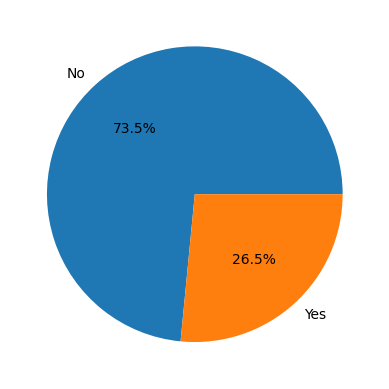

In [ ]:
#visualizing using Pi chart
import matplotlib.pyplot as plt
from enum import auto
plt.pie(sizes,labels=names,autopct='%0.1f%%')
plt.show()

b. Build a bar plot to show the distribution of 'internet service'.

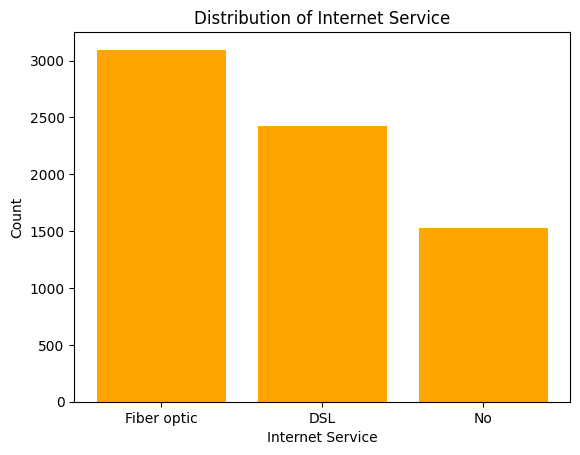

In [ ]:
import matplotlib.pyplot as plt


plt.xlabel('Internet Service')  # Label for X-axis
plt.ylabel('Count')  # Label for Y-axis
plt.title('Distribution of Internet Service')  # Title of the plot

plt.bar(df['InternetService'].value_counts().keys().tolist(),
        df['InternetService'].value_counts().tolist(),
        color='orange')

plt.show()


In [ ]:
# as in the result we could see most of the customer are having atleast one kind of service and fiber optic is the first choice for that.

C. Model Building :

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Dropout



# Selecting the feature and target variable
X = df[['tenure']].values  # Using 'tenure' as input
y = df['Churn'].map({'Yes': 1, 'No': 0}).values  # Convert 'Churn' to binary (1/0)

# Spliting data into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizing 'tenure' feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Defining the model
model = Sequential([
    Dense(12, activation='relu', input_shape=(1,)),  # Input layer with 12 nodes
    Dense(8, activation='relu'),                     # Hidden layer with 8 nodes
    Dense(1, activation='sigmoid')
                      # Output layer (binary classification)
])

# Compiling the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Training the model
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5528 - loss: 0.6868 - val_accuracy: 0.7353 - val_loss: 0.5229
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7419 - loss: 0.5194 - val_accuracy: 0.7353 - val_loss: 0.5059
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7316 - loss: 0.5270 - val_accuracy: 0.7353 - val_loss: 0.5031
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7315 - loss: 0.5165 - val_accuracy: 0.7353 - val_loss: 0.5016
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7286 - loss: 0.5108 - val_accuracy: 0.7353 - val_loss: 0.5006
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7328 - loss: 0.5194 - val_accuracy: 0.7353 - val_loss: 0.4992
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7330 - loss: 0.5142 - val_accuracy: 0.7353 - val_loss: 0.5000
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7368 - loss: 0.5163 - val_accuracy: 0.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabel'

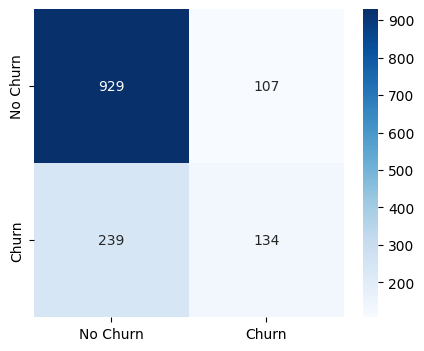

In [ ]:
# Predicting on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary output

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Plot for confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Accuracy: {accuracy:.2f})")
plt.show()


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabel'

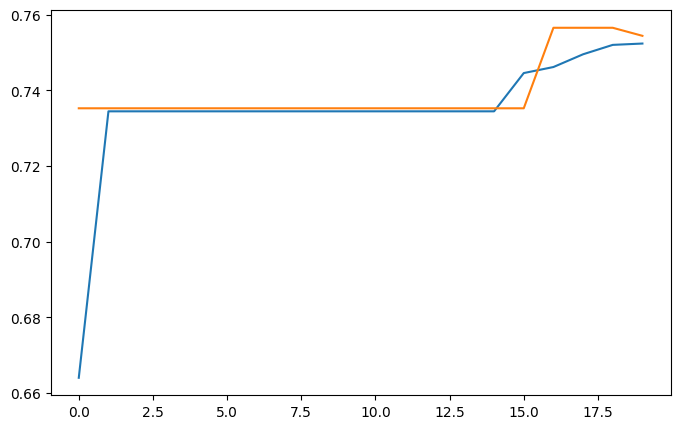

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


The early saturation in the graph or result may be because of the only feature we are using.

b. Model buildint with some hyperparameter tuning.

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6526 - loss: 0.6410 - val_accuracy: 0.7353 - val_loss: 0.5188
Epoch 2/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7264 - loss: 0.5501 - val_accuracy: 0.7353 - val_loss: 0.5087
Epoch 3/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7320 - loss: 0.5331 - val_accuracy: 0.7353 - val_loss: 0.5057
Epoch 4/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7434 - loss: 0.5134 - val_accuracy: 0.7353 - val_loss: 0.5045
Epoch 5/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7349 - loss: 0.5345 - val_accuracy: 0.7353 - val_loss: 0.5030
Epoch 6/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7417 - loss: 0.5211 - val_accuracy: 0.7353 - val_loss: 0.5008
Epoch 7/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7299 - loss: 0.5326 - val_accuracy: 0.7353 - val_loss: 0.5003
Epoch 8/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7380 - loss: 0.5238 - val_accuracy: 0.7353

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabel'

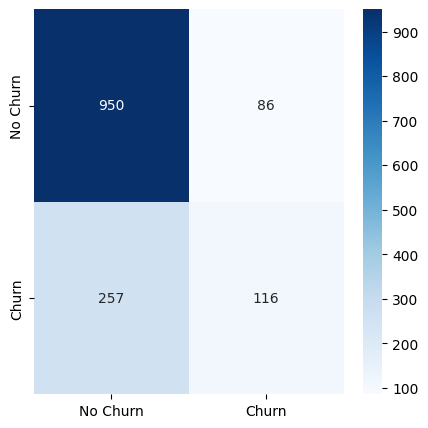

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming X is 'tenure' and y is 'Churn' (binary: 0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizing the feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model building
model = Sequential([
    Dense(12, activation='relu', input_shape=(1,)),
    Dropout(0.3),  # Dropout after input layer
    Dense(8, activation='relu'),
    Dropout(0.2),  # Dropout after hidden layer
    Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training the model
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), verbose=1)

# Predicting on test set
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Building the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot for Accuracy vs. Epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabel'

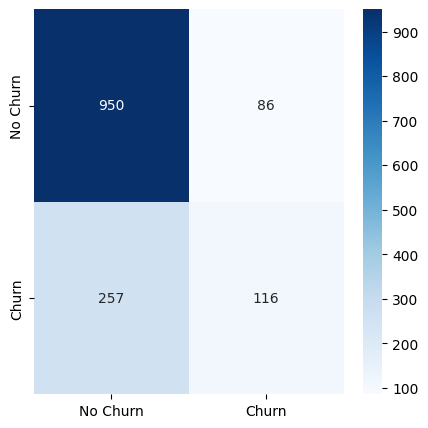

In [ ]:
import matplotlib.pyplot as plt

# Build the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabel'

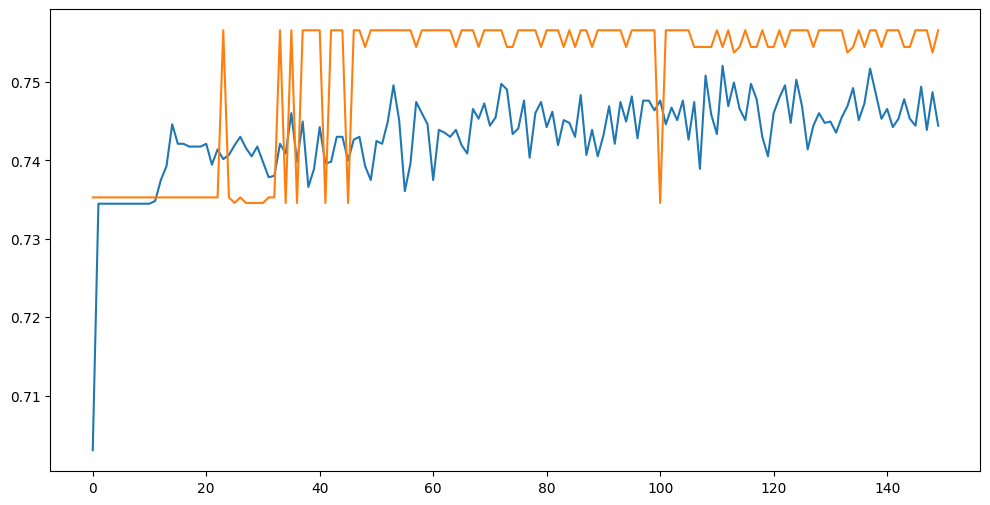

In [ ]:
# Plotting Accuracy vs. Epochs
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()

c.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Selecting required features and target
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn'].map({'Yes': 1, 'No': 0})  # Convert 'Yes'/'No' to 1/0

# Handling missing values in 'TotalCharges' (if any)
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X.fillna(X.median(), inplace=True)

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the Sequential Model
model = Sequential([
    Dense(12, activation='relu', input_shape=(3,)),  # Input layer with 12 nodes
    Dense(8, activation='relu'),  # Hidden layer with 8 nodes
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training the model
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), batch_size=32, verbose=1)




Epoch 1/150


<ipython-input-46-5acf1c253e57>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
<ipython-input-46-5acf1c253e57>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.median(), inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=a

177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7303 - loss: 0.6030 - val_accuracy: 0.7353 - val_loss: 0.4881
Epoch 2/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7264 - loss: 0.5032 - val_accuracy: 0.7353 - val_loss: 0.4576
Epoch 3/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7361 - loss: 0.4810 - val_accuracy: 0.7353 - val_loss: 0.4501
Epoch 4/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7315 - loss: 0.4730 - val_accuracy: 0.7970 - val_loss: 0.4484
Epoch 5/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7760 - loss: 0.4867 - val_accuracy: 0.7999 - val_loss: 0.4449
Epoch 6/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7830 - loss: 0.4691 - val_accuracy: 0.7999 - val_loss: 0.4439
Epoch 7/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7845 - loss: 0.4735 - val_accuracy: 0.8020 - val_loss: 0.4422
Epoch 8/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7880 - loss: 0.4665 - val_accuracy: 0.7984

In [ ]:
# Predicting on test set
y_pred = (model.predict(X_test) > 0.5).astype(int)



45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Confusion Matrix:
 [[955  81]
 [195 178]]


In [ ]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.8041163946061036


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabel'

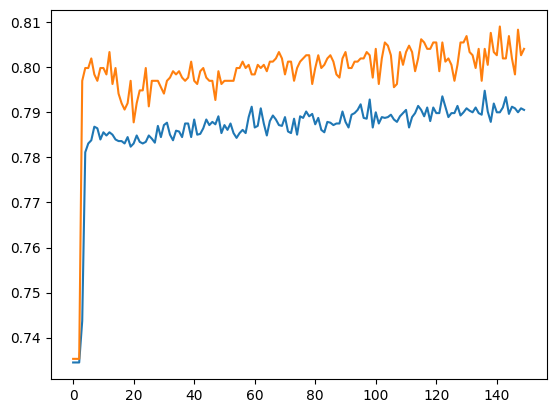

In [ ]:
# Plot Accuracy vs Epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.show()